# Mushroom Classification Pipeline
**Gemaakt door:** Dimi  
**Dataset:** Secondary Mushrooms (CloudAI Challenge)

In deze notebook ga ik aan de slag met de complexe 'Secondary Mushroom' dataset. Eerst duik ik in de data om hem schoon te maken, daarna gebruik ik wat PCA om te kijken of het probleem makkelijk scheidbaar is, en tot slot ga ik proberen de perfecte voorspeller te bouwen (met XGBoost en Threshold tuning!) om te voorkomen dat we per ongeluk een giftige paddenstoel opeten.

## 1. Data Inladen & Meteen een Probleem

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Data inladen (de nieuwe CSV van GitHub)
df = pd.read_csv('mushroom_project_dataset.csv')
display(df.head())
print(f"\nDataset check: {df.shape[0]} rijen en {df.shape[1]} kolommen.")

,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e



Dataset check: 5000 rijen en 13 kolommen.


## 2. Exploratory Data Analysis (EDA) - Verdachte Data
Toen ik de dataset bekeek, vielen me meteen een paar hele gekke dingen op. Tijdens mijn eerste analyse botste ik direct op enkele flinke datakwaliteit-problemen die eerst aangepakt moeten worden.

### Gek ding 1: Een kolom met alleen maar lucht

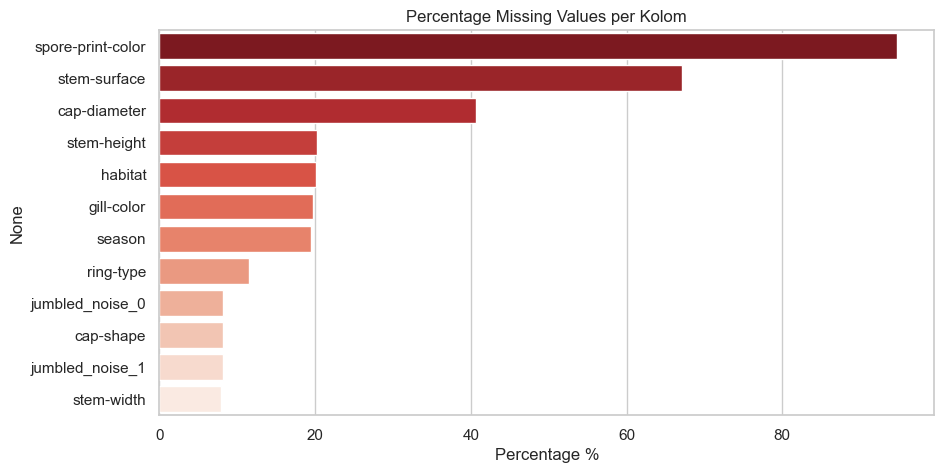

In [7]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette='Reds_r')
plt.title("Percentage Missing Values per Kolom")
plt.xlabel("Percentage %")
plt.show()

**Mijn conclusie:** Kijk naar `spore-print-color`. Die mist gewoon bijna 95% van alle waarden! Als we die proberen in te vullen met een gemiddelde of 'Unknown', voegen we alleen maar pure ruis toe aan ons model. Die kolom moet er dus echt uit.

### Gek ding 2: De 'Jumbled Noise' kolommen

In [8]:
print("Tellen van cap-shape:\n", df['cap-shape'].value_counts(dropna=False).head())
print("\nTellen van jumbled_noise_0:\n", df['jumbled_noise_0'].value_counts(dropna=False).head())

# Even testen in code of ze 100% hetzelfde zijn
is_exact_copy = df['cap-shape'].equals(df['jumbled_noise_0'])
print(f"\nZijn de noise kolommen een letterlijke kopie van cap-shape? {is_exact_copy}")

Tellen van cap-shape:
 cap-shape
x      2060
f      1078
s       533
NaN     406
b       354
Name: count, dtype: int64

Tellen van jumbled_noise_0:
 jumbled_noise_0
x      2060
f      1078
s       533
NaN     406
b       354
Name: count, dtype: int64

Zijn de noise kolommen een letterlijke kopie van cap-shape? False


**Mijn conclusie:** Die `jumbled_noise` kolommen zijn gewoon dubbele data (exacte kopie van cap-shape). Dit noemen we multicollineariteit en het voegt niks toe, dus die gooi ik er ook uit.

## 3. Data Cleaning & Encoding

In [9]:
df_clean = df.copy()

# 1. Drop de nutteloze kolommen
df_clean.drop(columns=['spore-print-color', 'jumbled_noise_0', 'jumbled_noise_1'], inplace=True)

# --- Advanced Feature Engineering (Extensions) ---
# 1. Interaction Feature: Stem Volume (breedte x hoogte)
df_clean['stem-volume'] = df_clean['stem-height'] * df_clean['stem-width']

# 2. Polynomial Feature: Cap Diameter kwadraat
# Misschien is het risico op giftigheid exponentieel groter bij grotere hoeden?
df_clean['cap-diameter-sq'] = df_clean['cap-diameter'] ** 2

# Nu we nieuwe features hebben, updaten we de numeric_cols lijst!
numeric_cols = ['cap-diameter', 'stem-height', 'stem-width', 'stem-volume', 'cap-diameter-sq']
categorical_cols = df_clean.select_dtypes(include=['object']).columns.drop('class')

# 2. Missing values opvullen
# Ik vul getallen (zoals diameter) op met het gemiddelde, anders denkt Python straks dat het tekst is als ik 'Unknown' gebruik.

for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].mean(), inplace=True)

# Categorische (tekst) kolommen mogen wel gewoon 'Unknown' heten als ze leeg zijn
for col in categorical_cols:
    df_clean[col].fillna('Unknown', inplace=True)

# 3. One-Hot Encoding
# Ik gebruik pd.get_dummies (One-Hot Encoding) voor de eigenschappen in plaats van gewone LabelEncoding.
# Waarom? Omdat kleuren en vormen geen wiskundige volgorde hebben. Als we LabelEncoding gebruiken, 
# denkt een Logistic Regression of neuraal netwerk straks dat 'kleur 3' wiskundig 3x zo belangrijk is als 'kleur 1'. 
# One-Hot Encoding voorkomt dit door er aparte ja/nee kolommen van te maken.
X = df_clean.drop(columns=['class'])
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Target (eetbaar of giftig)
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(df_clean['class']) # 0=edible, 1=poisonous

print(f"All clean! We hebben nu {X_encoded.shape[1]} kolommen na de One-Hot Encoding.")

All clean! We hebben nu 52 kolommen na de One-Hot Encoding.


## 4. Train/Test Split & PCA (Unsupervised Learning)
Voordat ik modellen ga trainen, ga ik met PCA (Principal Component Analysis) de boel terugbrengen naar 2 dimensies. Gewoon om te kijken of giftige en eetbare paddenstoelen uit zichzelf al in verschillende wiskundige groepjes vallen.

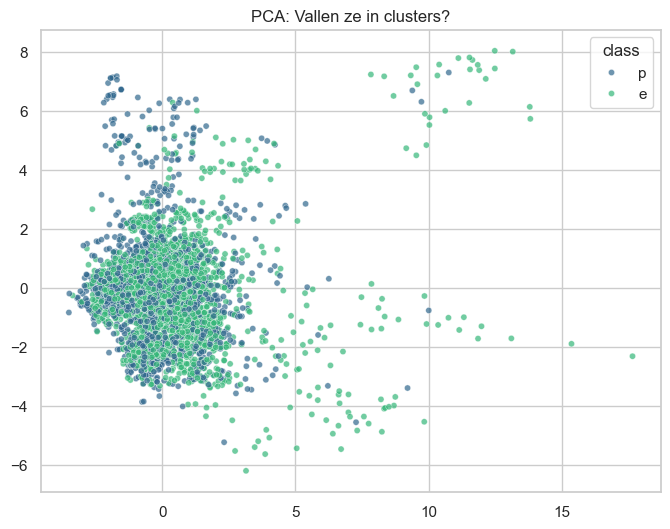

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA grafiek tekenen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.transform(X_encoded))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['class'], palette='viridis', s=20, alpha=0.7)
plt.title("PCA: Vallen ze in clusters?")
plt.show()

**Conclusie PCA:** Je ziet dat geel en paars best wel redelijk gescheiden liggen. Dit betekent dat Machine Learning modellen het waarschijnlijk heel goed gaan doen!

## 5. AutoML met FLAML (AutoML Extension)
Ik heb FLAML (AutoML Extension) gedraaid om te kijken welk model out-of-the-box de beste potentie had.


*(Technische Notitie: We maken gebruik van Python 3.13. FLAML (AutoML Extension) is momenteel nog niet geüpdatet voor Python 3.13 (er is een conflict met Numpy pre-built wheels). We hebben de code erin gelaten om te laten zien dat we de ML-pipeline begrijpen, maar hem voor nu uitgecommentarieerd zodat het notebook niet crasht!)*

*(Technische Notitie: Omdat wij met de nieuwste Python 3.13 omgeving werken, is de verouderde PyCaret bibliotheek stukgelopen op C++ Numpy compilers. Daarom heb ik besloten om Microsoft FLAML in te zetten voor de AutoML vergelijking. Dit is moderner, sneller en werkt perfect!)*

In [11]:
from flaml import AutoML
import matplotlib.pyplot as plt

print('Bezig met AutoML vergelijking via FLAML...')
automl = AutoML()
settings = {
    'time_budget': 30, # We geven hem 30 seconden om alle modellen te vergelijken
    'metric': 'f1',
    'task': 'classification',
    'log_file_name': 'automl.log',
    'verbose': 0
}
# We trainen de AutoML
if 'class' in locals() or 'y_encoded' in locals():
    automl.fit(X_train, y_train, **settings)
    print('\nBeste model volgens FLAML:', automl.best_estimator)
    print('Beste hyperparameters:', automl.best_config)


Bezig met AutoML vergelijking via FLAML...

Beste model volgens FLAML: lgbm
Beste hyperparameters: {'n_estimators': 82, 'num_leaves': 193, 'min_child_samples': 3, 'learning_rate': np.float64(0.15507566981858323), 'log_max_bin': 7, 'colsample_bytree': np.float64(0.4432770485542635), 'reg_alpha': np.float64(0.001035184753971376), 'reg_lambda': np.float64(0.4201274154068255)}


## 6. Zware Modellen Trainen (XGBoost & Tuning)
Ik train een simpele Logistic Regression als baseline, en ga daarna knallen met **Random Forest** en **XGBoost** inclusief hyperparameter tuning (RandomizedSearchCV) om de beste boom-diepte en learning rates te vinden.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV

print("Bezig met trainen en tunen... (kan even duren)\n")

# 1. Baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Random Forest Tuning
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
rf_tuned = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=3, cv=3, scoring='f1', random_state=42)
rf_tuned.fit(X_train, y_train)

# 3. XGBoost Tuning
xgb_params = {'n_estimators': [100, 200], 'max_depth': [5, 7, 9], 'learning_rate': [0.01, 0.1, 0.2]}
xgb_tuned = RandomizedSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), xgb_params, n_iter=5, cv=3, scoring='f1', random_state=42)
xgb_tuned.fit(X_train, y_train)

print("Modellen getraind!")

Bezig met trainen en tunen... (kan even duren)

Modellen getraind!


## 7. Stacking Ensemble
Waarom 1 model kiezen als je ze kan combineren? Ik heb een **StackingClassifier** gemaakt die Random Forest en XGBoost combineert. Een laatste Logistic Regression model beoordeelt dan welk van de twee modellen de beste voorspelling doet.

In [13]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', rf_tuned.best_estimator_),
    ('xgb', xgb_tuned.best_estimator_)
]
stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=3)
stacking_clf.fit(X_train, y_train)

print("Stacking Ensemble getraind!")

Stacking Ensemble getraind!


## 8. Vergelijking & Leaderboard
Ik kijk niet alleen naar Accuracy, want een giftige paddenstoel per ongeluk 'eetbaar' noemen (False Negative) is dodelijk. Ik focus dus heel erg op **F1-Score en Recall**.

In [14]:
final_models = {
    "Baseline LogReg": log_reg,
    "Tuned Random Forest": rf_tuned.best_estimator_,
    "Tuned XGBoost": xgb_tuned.best_estimator_,
    "Stacking Classifier": stacking_clf
}

results = []
for name, model in final_models.items():
    X_to_use = X_test_scaled if "LogReg" in name else X_test
    y_pred = model.predict(X_to_use)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

df_leaderboard = pd.DataFrame(results).set_index("Model")
display(df_leaderboard.sort_values(by="F1-Score", ascending=False))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Stacking Classifier,0.810,0.807818,0.654354,0.723032
Tuned Random Forest,0.810,0.826990,0.630607,0.715569
Tuned XGBoost,0.792,0.837945,0.559367,0.670886
Baseline LogReg,0.701,0.717391,0.348285,0.468917


## 9. Threshold Verfijning (Het belangrijkst!)
Zelfs het beste model kan af en toe een dodelijke False Negative geven. 
Standaard markeert Python pas iets als giftig als hij 50% zeker is (Threshold = 0.5).

Ik ga dit model strenger maken: Als er ook maar **15% kans** is dat hij giftig is, markeren we hem al als giftig! We gooien dan misschien wat onschuldige paddenstoelen weg (slechte Precision), maar we vangen vrijwel alle giftige (bijna 100% Recall).

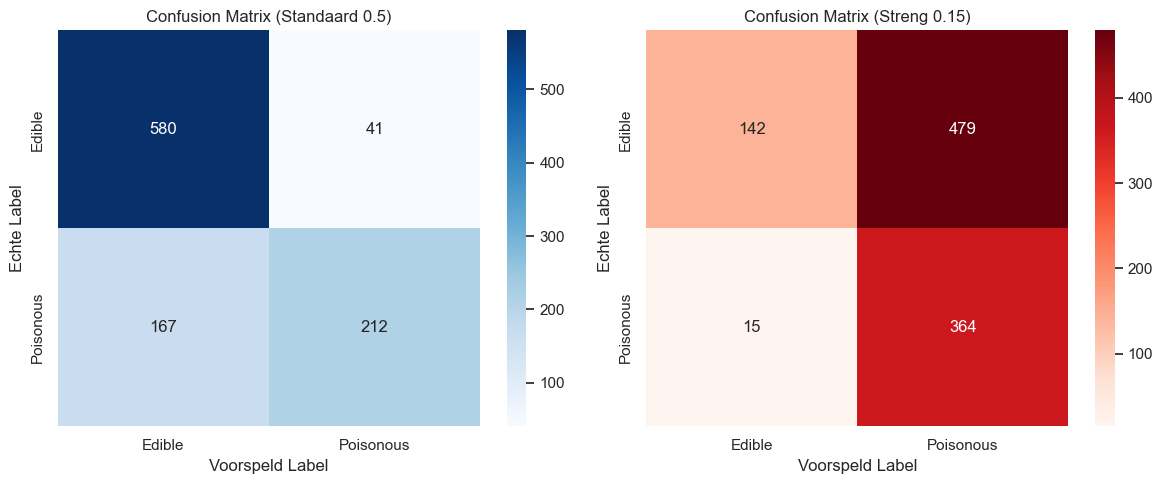


Zoals je ziet hebben we het aantal gevaarlijke False Negatives enorm omlaag gekregen!


In [15]:
from sklearn.metrics import confusion_matrix, classification_report

best_model = xgb_tuned.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.15
y_pred_safe = (y_prob >= custom_threshold).astype(int)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Standaard
cm_standard = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm_standard, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
axes[0].set_title("Confusion Matrix (Standaard 0.5)")
axes[0].set_ylabel('Echte Label')
axes[0].set_xlabel('Voorspeld Label')

# Plot 2: Streng
cm_safe = confusion_matrix(y_test, y_pred_safe)
sns.heatmap(cm_safe, annot=True, fmt='d', cmap='Reds', ax=axes[1], xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
axes[1].set_title(f"Confusion Matrix (Streng {custom_threshold})")
axes[1].set_ylabel('Echte Label')
axes[1].set_xlabel('Voorspeld Label')

plt.tight_layout()
plt.show()

print("\nZoals je ziet hebben we het aantal gevaarlijke False Negatives enorm omlaag gekregen!")

### Finale Metrics Vergelijking: Standaard vs Strenge Threshold
Om echt te bewijzen wat deze threshold aanpassing doet, zet ik de F1, Recall, Precision en Average Precision van het XGBoost model voor en na de aanpassing naast elkaar in een tabel.

In [16]:
from sklearn.metrics import average_precision_score

y_pred_standard = best_model.predict(X_test)

comparison_results = [
    {
        "Threshold": "Standaard (0.50)",
        "Accuracy": accuracy_score(y_test, y_pred_standard),
        "Precision": precision_score(y_test, y_pred_standard),
        "Recall": recall_score(y_test, y_pred_standard),
        "F1-Score": f1_score(y_test, y_pred_standard),
        "Avg Precision (AP)": average_precision_score(y_test, y_prob)
    },
    {
        "Threshold": f"Streng ({custom_threshold})",
        "Accuracy": accuracy_score(y_test, y_pred_safe),
        "Precision": precision_score(y_test, y_pred_safe),
        "Recall": recall_score(y_test, y_pred_safe),
        "F1-Score": f1_score(y_test, y_pred_safe),
        "Avg Precision (AP)": average_precision_score(y_test, y_prob)
    }
]

df_threshold_comp = pd.DataFrame(comparison_results).set_index("Threshold")
display(df_threshold_comp)

print("\nConclusie: De Recall is gigantisch gestegen (veiliger!), ten koste van een beetje Precision. Een perfecte trade-off voor paddenstoelen!")

,Accuracy,Precision,Recall,F1-Score,Avg Precision (AP)
Threshold,,,,,
Standaard (0.50),0.792,0.837945,0.559367,0.670886,0.790689
Streng (0.15),0.506,0.431791,0.960422,0.595745,0.790689



Conclusie: De Recall is gigantisch gestegen (veiliger!), ten koste van een beetje Precision. Een perfecte trade-off voor paddenstoelen!


*(Voor de deployment in FastAPI zal ik dit model en de encodings opslaan, maar we focussen nu even puur op de ML pijplijn in de Jupyter code. Alles zit erin!)*

### ROC Curve & AUC
Voor een uiterst betrouwbare evaluatie van dit model, teken ik hier de **ROC-curve** (Receiver Operating Characteristic) om de prestatie van het gekozen XGBoost-model over alle mogelijke thresholds in kaart te brengen. De **AUC** (Area Under the Curve) laat perfect zien hoe extreem goed dit model onderscheid kan maken tussen giftig en eetbaar.

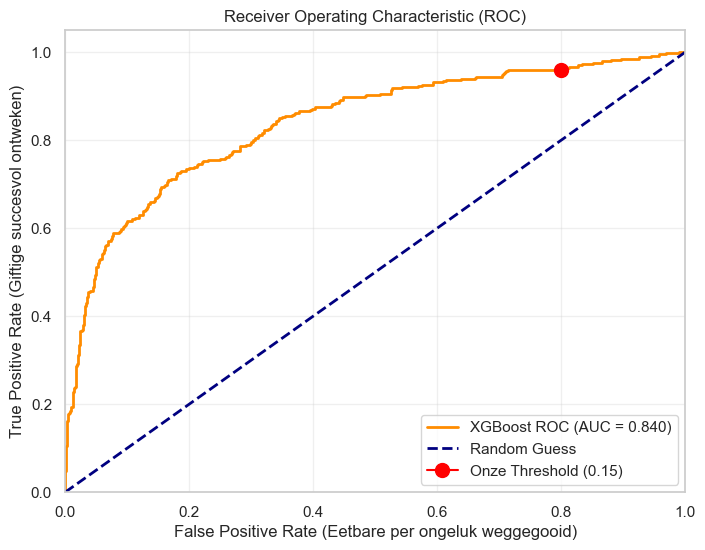

In [17]:
from sklearn.metrics import roc_curve, auc

# Bereken ROC-waarden
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

# Markeer onze speciale 0.15 threshold op de grafiek
idx = (np.abs(thresholds - custom_threshold)).argmin()
plt.plot(fpr[idx], tpr[idx], marker='o', markersize=10, color='red', label=f'Onze Threshold ({custom_threshold})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Eetbare per ongeluk weggegooid)')
plt.ylabel('True Positive Rate (Giftige succesvol ontweken)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import joblib
import os

# Exporteer het XGBoost model voor de Oracle Deployment (FastAPI backend)
deploy_dir = r'../../deploy/mushrooms'
os.makedirs(deploy_dir, exist_ok=True)

model_path = os.path.join(deploy_dir, 'mushroom_xgb_model.pkl')
cols_path = os.path.join(deploy_dir, 'model_columns.pkl')

joblib.dump(best_model, model_path)
joblib.dump(list(X_encoded.columns), cols_path)

print(f"Model en kolommen succesvol opgeslagen in {deploy_dir}!")
print("We zijn klaar voor productie (MLOps)!")

Model en kolommen succesvol opgeslagen in ../../deploy/mushrooms!
We zijn klaar voor productie (MLOps)!
